In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [3]:
data = pd.read_csv("Housing.csv")

# One-hot encoding for categorical columns
data = pd.get_dummies(data, drop_first=True)

# Features and Target
X = data.drop("price", axis=1)
y = data["price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
baseline = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

baseline.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_base = baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


c:\Users\Prathmesh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 25349389811712.0000 - mae: 4727422.0000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349383520256.0000 - mae: 4727421.5000 - val_loss: 24781588004864.0000 - val_mae: 4623896.0000
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349373034496.0000 - mae: 4727420.5000 - val_loss: 24781577519104.0000 - val_mae: 4623895.5000
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25349366743040.0000 - mae: 4727419.5000 - val_loss: 24781567033344.0000 - val_mae: 4623894.5000
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349349965824.0000 - mae: 4727418.0000 - val_loss: 24781552353280.0000 - val_mae: 4623893.0000
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349333188608.0000 - mae: 4727416.5000 - val_loss: 24781531381760.0000 - val_mae: 4623891.0000
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349308022784.0000 - mae: 

In [7]:
l2_model = keras.Sequential([
    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(1)
])

l2_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_l2 = l2_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 25349389811712.0000 - mae: 4727422.5000 - val_loss: 24781598490624.0000 - val_mae: 4623898.0000
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349385617408.0000 - mae: 4727422.0000 - val_loss: 24781592199168.0000 - val_mae: 4623896.5000
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349379325952.0000 - mae: 4727421.0000 - val_loss: 24781585907712.0000 - val_mae: 4623896.0000
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349375131648.0000 - mae: 4727420.0000 - val_loss: 24781577519104.0000 - val_mae: 4623895.0000
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349360451584.0000 - mae: 4727419.0000 - val_loss: 24781562839040.0000 - val_mae: 4623894.0000
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349347868672.0000 - mae: 4727417.5000 - val_loss: 24781546061824.0000 - val_mae: 4623892.0000
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349331091456.00

In [8]:
dropout_model = keras.Sequential([

    layers.Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    layers.Dropout(0.5),

    layers.Dense(
        32,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(1)
])

dropout_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 25349387714560.0000 - mae: 4727422.0000 - val_loss: 24781594296320.0000 - val_mae: 4623896.5000
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349383520256.0000 - mae: 4727421.0000 - val_loss: 24781590102016.0000 - val_mae: 4623896.5000
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349375131648.0000 - mae: 4727420.5000 - val_loss: 24781579616256.0000 - val_mae: 4623895.5000
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349364645888.0000 - mae: 4727419.5000 - val_loss: 24781571227648.0000 - val_mae: 4623894.5000
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25349358354432.0000 - mae: 4727418.5000 - val_loss: 24781558644736.0000 - val_mae: 4623894.0000
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349343674368.0000 - mae: 4727417.0000 - val_loss: 24781543964672.0000 - val_mae: 4623891.5000
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25349322702848.00

In [9]:
loss, mae = baseline.evaluate(X_test, y_test)

pred = baseline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nBaseline Model")
print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30087455965184.0000 - mae: 5004328.5000 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Baseline Model
MAE : 5004328.5
RMSE: 5485203.3658911865


In [10]:
loss, mae = l2_model.evaluate(X_test, y_test)

pred = l2_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nL2 Regularization Model")
print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30095395782656.0000 - mae: 5004868.5000 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

L2 Regularization Model
MAE : 5004868.5
RMSE: 5485926.49341932


In [11]:
loss, mae = dropout_model.evaluate(X_test, y_test)

pred = dropout_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nDropout Model")
print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30099155976192.0000 - mae: 5005210.0000 
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002326B95FC70> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Dropout Model
MAE : 5005210.0
RMSE: 5486269.76881305


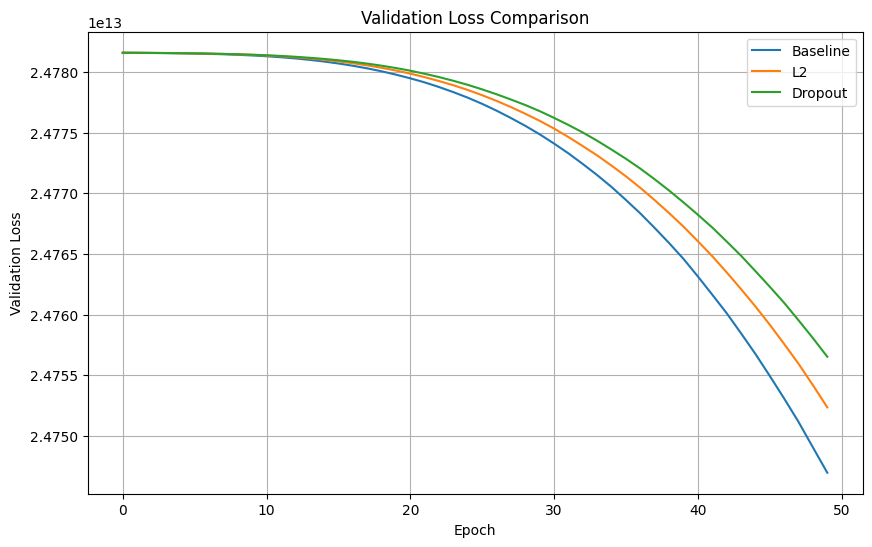

In [12]:
plt.figure(figsize=(10,6))

plt.plot(history_base.history['val_loss'], label='Baseline')

plt.plot(history_l2.history['val_loss'], label='L2')

plt.plot(history_dropout.history['val_loss'], label='Dropout')

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()